----------------------------

**Configuration**

-----------------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU, BatchNormalization, Dropout, Conv1D, MaxPooling1D, Flatten, GlobalAveragePooling1D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from imblearn.over_sampling import SMOTE

# --- Configuration & Hyperparameter ---

# --- Data Configuration ---

from google.colab import drive

drive.mount('/content/drive')
FILE_PATH = '/content/drive/MyDrive/grad dataset/Datasets/NF-BoT-IoT-v3.csv'
SAMPLE_SIZE = 600000
RANDOM_STATE = 42

# --- Data Features ---
FEATURE_COLS = [
    'IN_BYTES',
    'OUT_BYTES',
    'IN_PKTS',
    'OUT_PKTS',
    'L4_DST_PORT',
    'L4_SRC_PORT',
    'L7_PROTO',
    'PROTOCOL',
    'CLIENT_TCP_FLAGS',
    'SERVER_TCP_FLAGS',
    'SRC_TO_DST_AVG_THROUGHPUT',
    'MIN_TTL',
    'MAX_TTL',
    'TCP_WIN_MAX_IN',
    'TCP_WIN_MAX_OUT',
    'SRC_TO_DST_IAT_AVG',
    'FLOW_DURATION_MILLISECONDS'

]
LABEL_COL = "Attack"

# --- Splitting Ratios ---
TEST_SPLIT_SIZE = 0.1
VALIDATION_SPLIT_SIZE = 0.2
VAL_SPLIT_RATIO = VALIDATION_SPLIT_SIZE / (1.0 - TEST_SPLIT_SIZE)

# --- Model Hyperparameters ---
LEARNING_RATE = 0.001

# --- Training Hyperparameters ---
EPOCHS = 100
BATCH_SIZE = 256
EARLY_STOPPING_PATIENCE = 5
REDUCE_LR_PATIENCE = 3

# --- Plotting Configuration ---
HISTORY_PLOT_FILENAME = 'training_history.png'
REPORT_PLOT_FILENAME = 'classification_report_heatmap.png'
CONFUSION_MATRIX_FILENAME = 'confusion_matrix.png'
SMOTE_DISTRIBUTION_PLOT_FILENAME = 'smote_class_distribution.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
FEATURE_COLS = [
    'IN_BYTES',
    'OUT_BYTES',
    'IN_PKTS',
    'OUT_PKTS',
    'L4_DST_PORT',
    'L4_SRC_PORT',
    'L7_PROTO',
    'PROTOCOL',
    'CLIENT_TCP_FLAGS',
    'SERVER_TCP_FLAGS',
    'SRC_TO_DST_AVG_THROUGHPUT',
    'SRC_TO_DST_IAT_AVG',
    'MIN_TTL',
    'MAX_TTL',
    'TCP_WIN_MAX_IN',
    'TCP_WIN_MAX_OUT',
    'FLOW_DURATION_MILLISECONDS'

]



---



**Preprocess Data**



---



In [ ]:

# --- Load and Preprocess Data ---

print("Loading and preprocessing data...")
all_cols = FEATURE_COLS + [LABEL_COL]


# --- Load Data (Smart Sampling) ---
print("Loading data...")
# 1.full data loading
df_full = pd.read_csv(FILE_PATH, usecols=all_cols)

# 2. our piroity classes
important_classes = ['Theft', 'Benign']

# 3. split tha data
# first part for most important
df_important = df_full[df_full[LABEL_COL].isin(important_classes)]
important_target_count = 200000
# other classes
df_others = df_full[~df_full[LABEL_COL].isin(important_classes)]

print(f"Keep-all count ({important_classes}): {len(df_important)}")


if len(df_important) > 0:
    replace_flag_imp = len(df_important) < important_target_count
    df_important = df_important.sample(n=important_target_count, random_state=RANDOM_STATE, replace=replace_flag_imp)
else:
    df_important = pd.DataFrame()

# 4. SAMPLE_SIZE ==> 600k
remaining_size = SAMPLE_SIZE - len(df_important)

# 5. we will complete the sample with other
if remaining_size > 0:

    replace_flag_others = len(df_others) < remaining_size
    df_others_sampled = df_others.sample(n=remaining_size, random_state=RANDOM_STATE, replace=replace_flag_others)
else:
    df_others_sampled = pd.DataFrame()

# concat
df = pd.concat([df_important, df_others_sampled], axis=0)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Final Data Shape: {df.shape}")
print("Class counts in final sample:")
print(df[LABEL_COL].value_counts())




# --- Preprocess Labels ---
# -Log Transform ---
log_cols = [
    'IN_BYTES',
    'OUT_BYTES',
    'IN_PKTS',       # <---
    'OUT_PKTS',      # <---
    'SRC_TO_DST_AVG_THROUGHPUT',
    'FLOW_DURATION_MILLISECONDS',
    'SRC_TO_DST_IAT_AVG',
    'TCP_WIN_MAX_IN',
    'TCP_WIN_MAX_OUT'
]

df[LABEL_COL] = df[LABEL_COL].astype('category')
class_names_list = list(df[LABEL_COL].cat.categories)
df[LABEL_COL] = df[LABEL_COL].cat.codes
num_classes = df[LABEL_COL].nunique()

# --- Drop NaNs ---
df.dropna(inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Prepare X and Y
X = df.drop(columns=[LABEL_COL]).values
Y = df[LABEL_COL].values.reshape(-1, 1)

# Initialize and fit OneHotEncoder here to make it available globally
ohe = OneHotEncoder(sparse_output=False, categories='auto')
ohe.fit(Y)

# --- 3. Split Data ---
X_train_val, X_test, y_train_val, y_test_labels = train_test_split(
    X, Y, test_size=TEST_SPLIT_SIZE, random_state=RANDOM_STATE,
    shuffle=True, stratify=Y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=VAL_SPLIT_RATIO,
    random_state=RANDOM_STATE, shuffle=True, stratify=y_train_val
)

# --- 4.Scaling (StandardScaler أو MinMaxScaler) ---
print("Applying Scaling...")

#  StandardScaler
scaler = StandardScaler()

#  we need to try this also (i didn`t try)
# scaler = MinMaxScaler()

# لاحظ: بنعمل fit على الـ Train بس، وبعدين transform للباقي
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing (Log + Scaling) Complete.")

Loading and preprocessing data...
Loading data...
Keep-all count (['Theft', 'Benign']): 53604
Final Data Shape: (600000, 18)
Class counts in final sample:
Attack
Benign            194098
DoS               189893
DDoS              169603
Reconnaissance     40504
Theft               5902
Name: count, dtype: int64
Applying Scaling...
Preprocessing (Log + Scaling) Complete.


In [ ]:
pip install ctgan

In [ ]:
pip install sdv


In [ ]:

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata


print("Starting Balancing Process using CTGAN...")

# 1. تجميع الداتا (X و y) في جدول واحد عشان الـ CTGAN
# لازم نستخدم الداتا المعمولة لها Scaling (X_train_scaled)
df_train_balanced = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
df_train_balanced['Label'] = y_train.flatten()

# 2. aim columns
class_counts = df_train_balanced['Label'].value_counts()
target_count = class_counts.max() # هيساوي 194098 في حالتك
print(f"Target count for balancing: {target_count}")

# to sum all new data
new_data_list = [df_train_balanced]

# 3. to equal each class
for class_val, count in class_counts.items():
    if count < target_count:
        diff = target_count - count
        class_name = class_names_list[class_val] if 'class_names_list' in globals() else str(class_val)

        print(f"\n>>> Class '{class_name}' needs {diff} more samples to balance.")

        # metadata for classes
        subset = df_train_balanced[df_train_balanced['Label'] == class_val]

        # metadata
        metadata = SingleTableMetadata()
        metadata.detect_from_dataframe(data=subset)

        #   CTGAN train
        # we can increase the epochs more and more and moreeeeee
        print(f"    Training CTGAN for '{class_name}'...")
        synthesizer = CTGANSynthesizer(metadata, epochs=30, verbose=True)
        synthesizer.fit(subset)

        # توليد البيانات الناقصة
        print(f"    Generating {diff} samples...")
        # take care 3lshan al ramat
        batch_size = 10000
        generated_chunks = []
        for _ in range(0, diff, batch_size):
            current_batch = min(batch_size, diff - len(generated_chunks)*batch_size)
            if current_batch <= 0: break
            generated_chunks.append(synthesizer.sample(num_rows=current_batch))

        synthetic_data = pd.concat(generated_chunks, axis=0)
        new_data_list.append(synthetic_data)
        print(f"    Done augmenting '{class_name}'.")

# 4.  concat or merge
print("\nFinalizing dataset...")
df_final_balanced = pd.concat(new_data_list, axis=0)

#  (Shuffling)
df_final_balanced = df_final_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# 5.  split x and y
X_train_cnn = df_final_balanced.drop('Label', axis=1).values
# Reshape for CNN (3D)
X_train_cnn = X_train_cnn.reshape((X_train_cnn.shape[0], X_train_cnn.shape[1], 1))

# One-Hot Encoding للـ Labels
y_train_balanced = df_final_balanced['Label'].values
#
y_train_ohe_resampled = ohe.transform(y_train_balanced.reshape(-1, 1))

print("\n--- Balancing Complete ---")
print("New Class Distribution:")
print(df_final_balanced['Label'].value_counts())
print(f"Final X_train shape: {X_train_cnn.shape}")

Starting Balancing Process using CTGAN...
Target count for balancing: 135868

>>> Class 'DoS' needs 2943 more samples to balance.
    Training CTGAN for 'DoS'...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (0.15) | Discrim. (-0.03): 100%|██████████| 30/30 [04:17<00:00,  8.58s/it]


    Generating 2943 samples...
    Done augmenting 'DoS'.

>>> Class 'DDoS' needs 17146 more samples to balance.
    Training CTGAN for 'DDoS'...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (0.20) | Discrim. (-0.14): 100%|██████████| 30/30 [04:07<00:00,  8.24s/it]


    Generating 17146 samples...
    Done augmenting 'DDoS'.

>>> Class 'Reconnaissance' needs 107516 more samples to balance.
    Training CTGAN for 'Reconnaissance'...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-0.25) | Discrim. (-0.02): 100%|██████████| 30/30 [00:54<00:00,  1.81s/it]


    Generating 107516 samples...
    Done augmenting 'Reconnaissance'.

>>> Class 'Theft' needs 131736 more samples to balance.
    Training CTGAN for 'Theft'...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-0.92) | Discrim. (-0.20): 100%|██████████| 30/30 [00:08<00:00,  3.69it/s]


    Generating 131736 samples...
    Done augmenting 'Theft'.

Finalizing dataset...

--- Balancing Complete ---
New Class Distribution:
Label
4    135868
1    135868
2    135868
0    135868
3    135868
Name: count, dtype: int64
Final X_train shape: (679340, 17, 1)


saving data (for us)

In [ ]:
import joblib
import os

# 1. حدد مكان الحفظ في الدرايف عشان الملفات متتمسحش لما تقفل
# غير المسار ده لأي فولدر عندك في الدرايف
save_path = '/content/drive/MyDrive/NTA_Project_Data/'

# إنشاء الفولدر لو مش موجود
if not os.path.exists(save_path):
    os.makedirs(save_path)

print(f"Saving data to {save_path}...")

# 2. حفظ الداتا المتوازنة كملف CSV (عشان تقدر تفتحها وتشوفها لو حبيت)
df_final_balanced.to_csv(save_path + 'balanced_train_data.csv', index=False)

# 3. حفظ الـ Scaler و الـ OneHotEncoder (مهم جداً عشان الـ Test set)
# بنستخدم مكتبة joblib لأنها سريعة في حفظ كائنات الـ Sklearn
joblib.dump(scaler, save_path + 'my_scaler.pkl')
joblib.dump(ohe, save_path + 'my_encoder.pkl')

# 4. (اختياري) حفظ داتا الـ Test والـ Val عشان تضمن إنها ثابتة وماتتغيرش
# لاحظ: X_test_scaled و y_test_labels احنا كنا جهزناهم قبل كده
np.save(save_path + 'X_test.npy', X_test_scaled)
np.save(save_path + 'y_test.npy', y_test_labels)
np.save(save_path + 'X_val.npy', X_val_scaled)
np.save(save_path + 'y_val.npy', y_val)

print("✅ All files saved successfully!")

Saving data to /content/drive/MyDrive/NTA_Project_Data/...
✅ All files saved successfully!


to call the data  (for us)

In [ ]:
import pandas as pd
import numpy as np
import joblib
from google.colab import drive

# 1. Mount Drive (لو مش معمول)
drive.mount('/content/drive')

# نفس المسار اللي حفظت فيه
load_path = '/content/drive/MyDrive/NTA_Project_Data/'

print("Loading saved data...")

# 2. تحميل الداتا المتوازنة
df_final_balanced = pd.read_csv(load_path + 'balanced_train_data.csv')

# 3. تحميل الـ Scaler و Encoder
scaler = joblib.load(load_path + 'my_scaler.pkl')
ohe = joblib.load(load_path + 'my_encoder.pkl')

# 4. تحميل الـ Test و Val (لو كنت حفظتهم بصيغة npy)
X_test_scaled = np.load(load_path + 'X_test.npy')
y_test_labels = np.load(load_path + 'y_test.npy')
X_val_scaled = np.load(load_path + 'X_val.npy')
y_val = np.load(load_path + 'y_val.npy')

# 5. تجهيز الداتا للموديل (Reshape & Encode)
# فصل الـ X و y
X_train_ready = df_final_balanced.drop('Label', axis=1).values
y_train_ready = df_final_balanced['Label'].values

# Reshape for CNN (3D)
# عدد الأعمدة (Features) بيتجاب أوتوماتيك
n_features = X_train_ready.shape[1]
X_train_cnn = X_train_ready.reshape((X_train_ready.shape[0], n_features, 1))

# Reshape Val/Test for CNN (لو مش جاهزين)
X_val_cnn = X_val_scaled.reshape((X_val_scaled.shape[0], n_features, 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], n_features, 1))

# One-Hot Encoding للـ Labels
y_train_ohe_resampled = ohe.transform(y_train_ready.reshape(-1, 1))
y_val_ohe = ohe.transform(y_val.reshape(-1, 1))
y_test_ohe = ohe.transform(y_test_labels.reshape(-1, 1))

# عدد الكلاسات (عشان طبقة الـ Output في الموديل)
num_classes = y_train_ohe_resampled.shape[1]

print("✅ Data loaded and ready for training!")
print(f"Training Shape: {X_train_cnn.shape}")

---------------------




**Build Model**




-------------

In [ ]:


# --- Build Model ---

print("\nBuilding 1D-CNN model...")
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

input_shape_cnn = (X_train_cnn.shape[1], X_train_cnn.shape[2]) # (5, 1)

model = Sequential(name="1D-CNN_Model_for_5_Features")
model.add(Input(shape=input_shape_cnn))

# Convolutional Block 1
# Use a small kernel_size (e.g., 2 or 3) because we only have 5 features
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())


# Convolutional Block 2
model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# Flattening and Dense Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer=RMSprop(learning_rate=0.001),
                     loss='categorical_crossentropy', # Changed to categorical_crossentropy for one-hot encoded labels
                     metrics=['accuracy']
)

model.summary()


# --- Plot Model Diagram ---
print("\nGenerating model diagram...")

tf.keras.utils.plot_model(
    model,
    to_file='model_diagram.png',
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    rankdir='TB',
    dpi=96
)

# --- Prepare Validation and Test Data for CNN if not already done ---
# Assuming X_val_scaled, y_val, X_test_scaled, y_test_labels, and ohe are available from previous cells.
# Infer n_features from already prepared X_train_cnn or from X_val_scaled
n_features = X_train_cnn.shape[1] if 'X_train_cnn' in globals() else X_val_scaled.shape[1]

# Reshape Val/Test for CNN (3D)
X_val_cnn = X_val_scaled.reshape((X_val_scaled.shape[0], n_features, 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], n_features, 1))

# One-Hot Encoding for Labels
y_val_ohe = ohe.transform(y_val.reshape(-1, 1))
y_test_ohe = ohe.transform(y_test_labels.reshape(-1, 1))



# --- Define Callbacks & Train Model ---

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=REDUCE_LR_PATIENCE,
        min_lr=1e-6,
        verbose=1
    )
]

print("\nStarting model training with callbacks...")
history = model.fit(
    X_train_cnn, y_train_ohe_resampled, # Changed X_train_resampled to X_train_cnn
    validation_data=(X_val_cnn, y_val_ohe), # Changed X_val_scaled to X_val_cnn
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


# --- Evaluate Model & Print Results ---

print("\nEvaluating model on test set...")
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test_ohe, verbose=0) # Changed X_test_scaled to X_test_cnn

print("\n====================== RESULTS (Best Model) ======================")
best_epoch = 0
if history.history.get('val_loss'):
  best_epoch = np.argmin(history.history['val_loss'])
  print(f"Best validation performance found at epoch ~{best_epoch+1}")
  print(f"Training Loss at best epoch: {history.history['loss'][best_epoch]:.4f}")
  print(f"Training Accuracy at best epoch: {history.history['accuracy'][best_epoch]*100:.2f}%")
  print(f"Validation Loss at best epoch: {history.history['val_loss'][best_epoch]:.4f}")
  print(f"Validation Accuracy at best epoch: {history.history['val_accuracy'][best_epoch]*100:.2f}%")
else:
    print("No validation history recorded.")

print("--------------------------------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Building 1D-CNN model...


Model: "1D-CNN_Model_for_5_Features"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 17, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 17, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 17, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,085 (617.52 KB)

 Trainable params: 157,445 (615.02 KB)

 Non-trainable params: 640 (2.50 KB)


Generating model diagram...

Starting model training with callbacks...
Epoch 1/100
2654/2654 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.8896 - loss: 0.2854 - val_accuracy: 0.9209 - val_loss: 0.2032 - learning_rate: 0.0010
Epoch 2/100
2654/2654 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9347 - loss: 0.1696 - val_accuracy: 0.9333 - val_loss: 0.1876 - learning_rate: 0.0010
Epoch 3/100
2654/2654 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9398 - loss: 0.1581 - val_accuracy: 0.9368 - val_loss: 0.1742 - learning_rate: 0.0010
Epoch 4/100
2654/2654 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9423 - loss: 0.1515 - val_accuracy: 0.9351 - val_loss: 0.1727 - learning_rate: 0.0010
Epoch 5/100
2654/2654 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9438 - loss: 0.1468 - val_accuracy: 0.9375 - val_loss: 0.1763 - learning_rate: 0.0010
Epoch 6/100
2654/2654 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9454 - loss: 0.1441 - val_accuracy: 0.9369 - val_loss: 0.1801 - learning_rate:

----------

**Plot**

-------------


Plotting history...
Training history plot saved as training_history.png


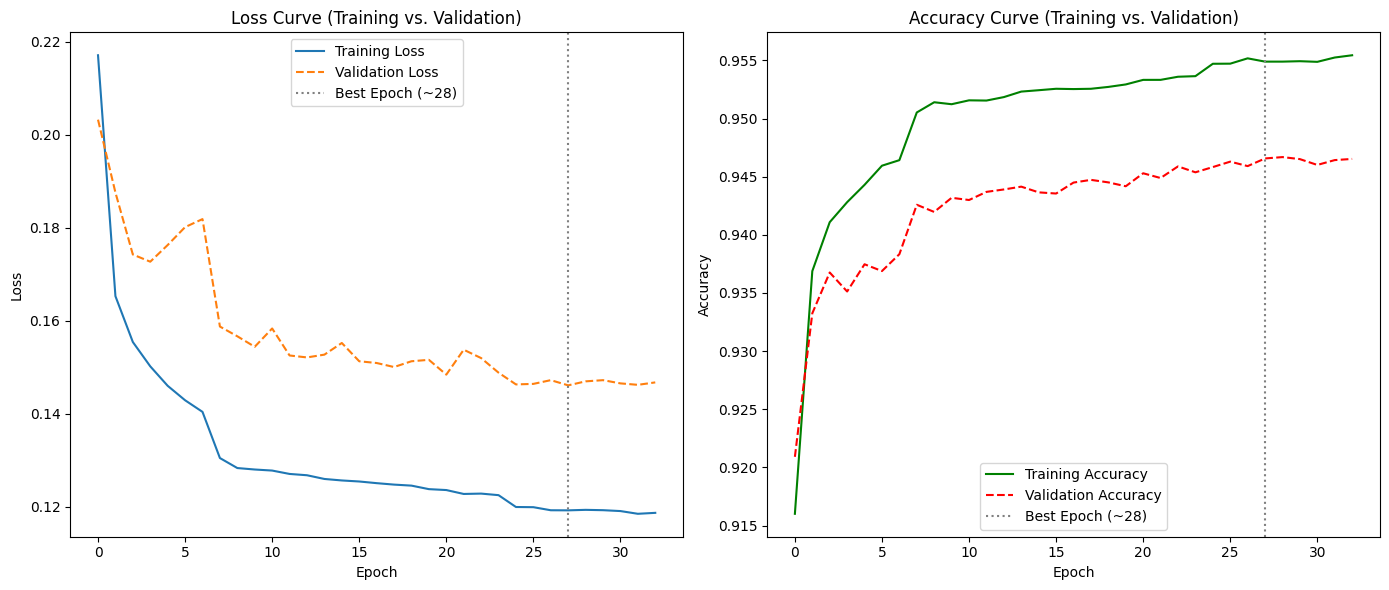


Generating classification report...
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step

--- Test Set Classification Report (Text) ---
                precision    recall  f1-score   support

        Benign       0.97      1.00      0.98     19410
          DDoS       0.95      0.89      0.92     16960
           DoS       0.91      0.95      0.93     18989
Reconnaissance       0.98      0.87      0.92      4051
         Theft       0.98      0.99      0.98       590

      accuracy                           0.94     60000
     macro avg       0.96      0.94      0.95     60000
  weighted avg       0.94      0.94      0.94     60000

Classification report heatmap saved as classification_report_heatmap.png


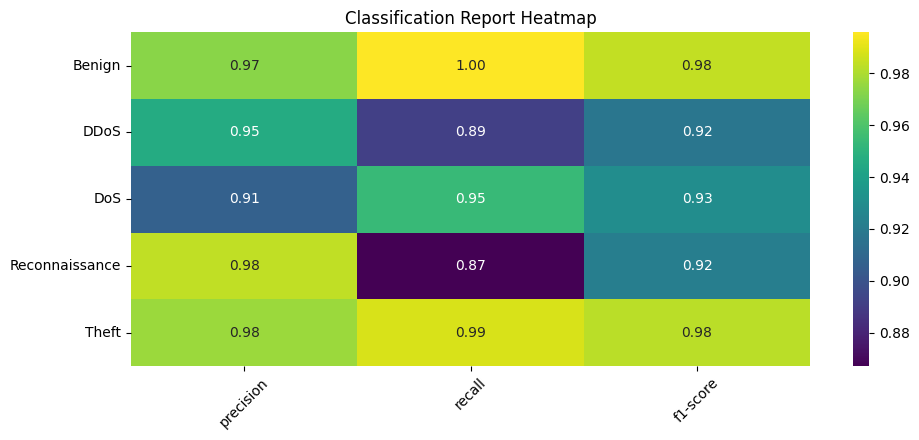


Generating Confusion Matrix...
Confusion matrix plot saved as confusion_matrix.png


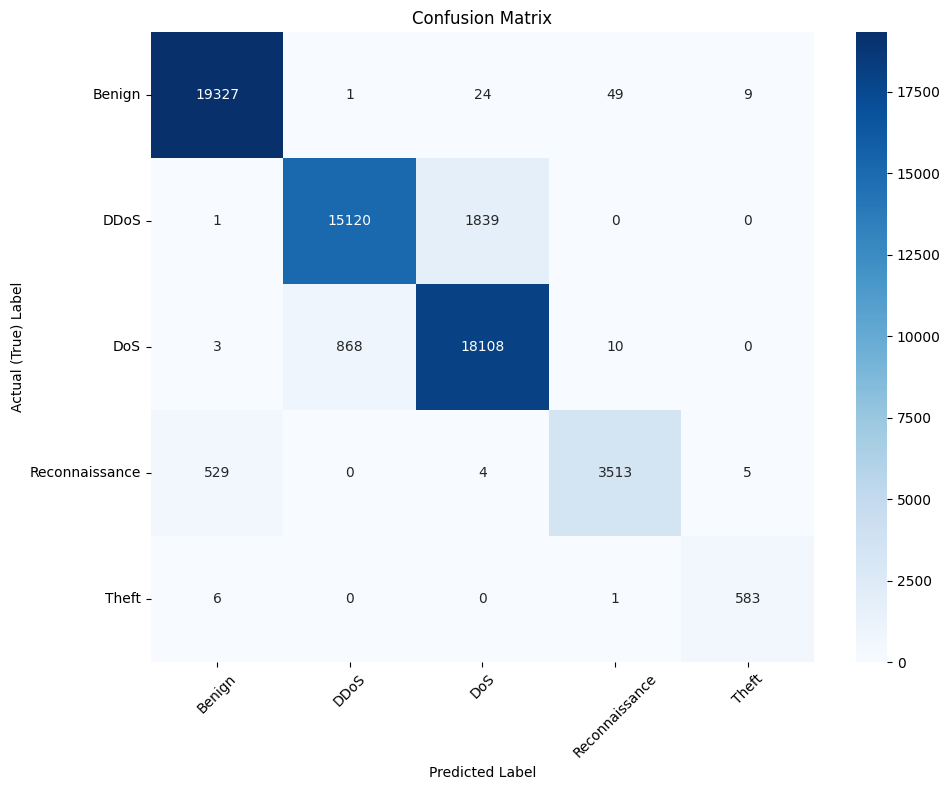


Process finished.


In [ ]:

# --- Plot History & Classification Report ---

print("\nPlotting history...")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve (Training vs. Validation)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.axvline(x=best_epoch, color='grey', linestyle=':', label=f'Best Epoch (~{best_epoch+1})')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
plt.title('Accuracy Curve (Training vs. Validation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.axvline(x=best_epoch, color='grey', linestyle=':', label=f'Best Epoch (~{best_epoch+1})')
plt.legend()
plt.tight_layout()
plt.savefig(HISTORY_PLOT_FILENAME)
print(f"Training history plot saved as {HISTORY_PLOT_FILENAME}")
plt.show()


print("\nGenerating classification report...")
y_pred_probs = model.predict(X_test_scaled)
preds_test_indices = np.argmax(y_pred_probs, axis=1) # Get 1D indices for reports

# --- Generate and print text report ---

report_text = classification_report(
    y_test_labels.flatten(), preds_test_indices, target_names=class_names_list, zero_division=0
)
print("\n--- Test Set Classification Report (Text) ---")
print(report_text)

# --- Generate and plot heatmap report ---
report_dict = classification_report(
    y_test_labels.flatten(), preds_test_indices, target_names=class_names_list, zero_division=0, output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
report_df_plot = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
report_df_plot = report_df_plot[['precision', 'recall', 'f1-score']]

plt.figure(figsize=(10, len(class_names_list) * 0.5 + 2))
sns.heatmap(report_df_plot, annot=True, cmap="viridis", fmt=".2f")
plt.title('Classification Report Heatmap')
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(REPORT_PLOT_FILENAME)
print(f"Classification report heatmap saved as {REPORT_PLOT_FILENAME}")
plt.show()

# --- Generate and plot Confusion Matrix ---
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_labels.flatten(), preds_test_indices)
plt.figure(figsize=(10, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names_list,
            yticklabels=class_names_list)
plt.title('Confusion Matrix')
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_FILENAME)
print(f"Confusion matrix plot saved as {CONFUSION_MATRIX_FILENAME}")
plt.show()

print("\nProcess finished.")